In [ ]:
¿Porqué una empresa podría no compartir sus datos reales?
¿Que sesgos existen al utilizar la información personal de los clientes?

In [2]:
pip install Faker

Note: you may need to restart the kernel to use updated packages.


In [3]:
#Importar librerias
from faker import Faker

In [4]:
import pandas as pd

In [5]:
import random

In [6]:
fake = Faker("es_MX")

In [7]:
# Generamos datos sintéticos: 100 registros
datos = []
for i in range(100):   
    datos.append({    
        "id_usuario": i + 1,  
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18, 67),
        "seguidores": random.randint(100, 5000),
        "plataforma": random.choice(
            ["Tiktok", "Instagram", "Youtube"]
        )
    })

In [8]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Srita. Silvia Centeno,franciscaherrera@example.org,39,1124,Youtube
1,2,Bernabé Cristian Meléndez,ericsegovia@example.net,35,3356,Youtube
2,3,Elias Jos Martínez Cuellar,tjiminez@example.com,32,1699,Youtube
3,4,Lic. Reina Montez,maria-elena69@example.com,40,327,Youtube
4,5,Lucas Emilio Candelaria Lemus,jorge-luis31@example.com,37,2435,Tiktok


In [9]:
#Estadistica descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.000000,100.000000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,Srita. Silvia Centeno,franciscaherrera@example.org,NaN,NaN,Tiktok
freq,NaN,1,1,NaN,NaN,38
mean,50.500000,NaN,NaN,44.460000,2290.100000,NaN
std,29.011492,NaN,NaN,13.704987,1347.994751,NaN
min,1.000000,NaN,NaN,18.000000,105.000000,NaN
25%,25.750000,NaN,NaN,33.750000,1115.750000,NaN
50%,50.500000,NaN,NaN,44.000000,2316.000000,NaN
75%,75.250000,NaN,NaN,57.000000,3352.250000,NaN


In [10]:
# Importar librerías para graficar
import seaborn as sns
import matplotlib.pyplot as plt

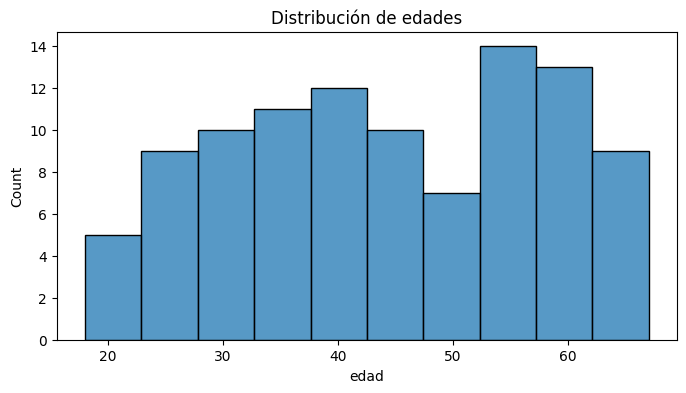

In [11]:
#Distribución de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribución de edades")
plt.show()

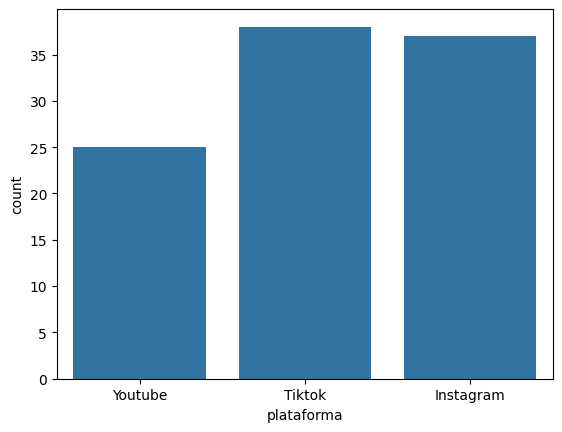

In [12]:
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [13]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [14]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i,"nombre"] = None

In [15]:
df_sucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  100 non-null    int64
 1   nombre      95 non-null     str  
 2   correo      100 non-null    str  
 3   edad        100 non-null    int64
 4   seguidores  100 non-null    int64
 5   plataforma  100 non-null    str  
dtypes: int64(3), str(3)
memory usage: 4.8 KB


In [16]:
# edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"] = -10

In [17]:
df_sucio.describe()["edad"]

count    100.000000
mean      41.550000
std       17.936687
min      -10.000000
25%       32.000000
50%       42.500000
75%       56.000000
max       67.000000
Name: edad, dtype: float64

In [18]:
# seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"seguidores"] = 500000

In [19]:
df_sucio.describe()["seguidores"]

count       100.00000
mean      27182.06000
std      109026.26177
min         105.00000
25%        1124.75000
50%        2402.50000
75%        3512.00000
max      500000.00000
Name: seguidores, dtype: float64

In [20]:
#Generamos correos invalidos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"correo"] = "correo_invalido"

In [21]:
df_sucio.describe(include=["str", "object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Srita. Silvia Centeno,correo_invalido,Tiktok
freq,1,5,38


In [22]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [24]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [25]:
#Estadisticas
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.00,95,100,100.00,100.00,100
unique,NaN,95,96,NaN,NaN,3
top,NaN,Srita. Silvia Centeno,correo_invalido,NaN,NaN,Tiktok
freq,NaN,1,5,NaN,NaN,38
mean,50.50,NaN,NaN,41.55,27182.06,NaN
std,29.01,NaN,NaN,17.94,109026.26,NaN
min,1.00,NaN,NaN,-10.00,105.00,NaN
25%,25.75,NaN,NaN,32.00,1124.75,NaN
50%,50.50,NaN,NaN,42.50,2402.50,NaN
75%,75.25,NaN,NaN,56.00,3512.00,NaN
